In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
import tensorflow_datasets as tfds

dataset, metadata = tfds.load(
    "cycle_gan/facades",
    with_info=True,
    as_supervised=True
)

print("Dataset loaded successfully!")
print(dataset)

ModuleNotFoundError: No module named 'importlib_resources'

In [4]:
import pathlib

dataset_name = "facades"

_URL = f"http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/{dataset_name}.tar.gz"

path_to_zip = tf.keras.utils.get_file(
    fname=f"{dataset_name}.tar.gz",
    origin=_URL,
    extract=True
)

path_to_zip = pathlib.Path(path_to_zip)
PATH = path_to_zip.parent / dataset_name

print("Dataset downloaded successfully!")
print("Dataset path:", PATH)

30168306/30168306 ━━━━━━━━━━━━━━━━━━━━ 23s 1us/step
Dataset downloaded successfully!
Dataset path: /root/.keras/datasets/facades


In [5]:
print("Dataset folders:")

for item in PATH.iterdir():
    print(item)

Dataset folders:


FileNotFoundError: [Errno 2] No such file or directory: '/root/.keras/datasets/facades'

In [6]:
import os
import tarfile
import urllib.request

url = "http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/facades.tar.gz"

download_path = "/content/facades.tar.gz"
extract_path = "/content"

print("Downloading Facades dataset...")

urllib.request.urlretrieve(url, download_path)

print("Download completed!")

print("Extracting dataset...")

with tarfile.open(download_path, "r:gz") as tar:
    tar.extractall(path=extract_path)

print("Extraction completed!")

PATH = "/content/facades"

print("Dataset path:", PATH)
print("Exists:", os.path.exists(PATH))

Download completed!
Extracting dataset...


/tmp/ipykernel_540/2512783212.py:19: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_path)


Extraction completed!
Dataset path: /content/facades
Exists: True


In [7]:
print("Dataset folders:")

for item in os.listdir(PATH):
    print(item)

Dataset folders:
val
test
train


In [8]:
train_path = os.path.join(PATH, "train")

train_images = os.listdir(train_path)

print("Number of training images:", len(train_images))
print("First 5 images:", train_images[:5])

Number of training images: 400
First 5 images: ['120.jpg', '222.jpg', '111.jpg', '101.jpg', '389.jpg']


In [9]:
sample_file = os.path.join(train_path, train_images[0])

sample_image = tf.io.read_file(sample_file)
sample_image = tf.io.decode_jpeg(sample_image)

print("Image shape:", sample_image.shape)

Image shape: (256, 512, 3)


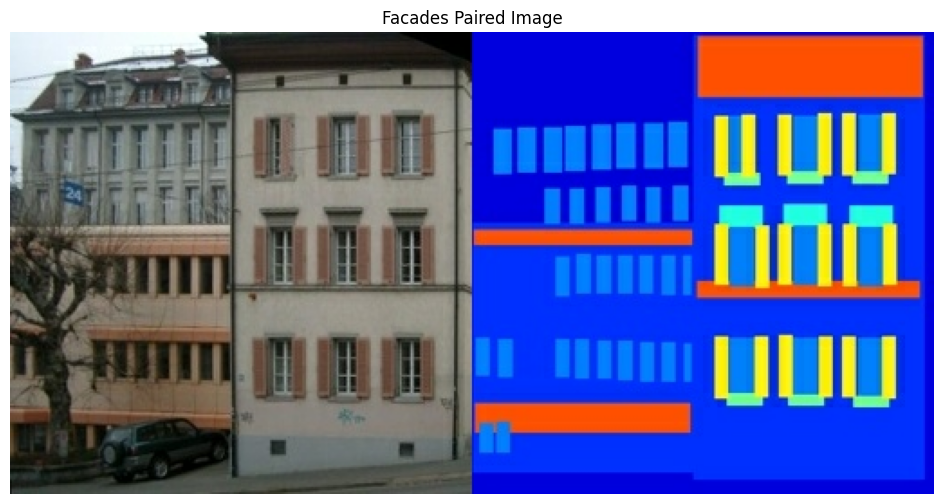

In [10]:
plt.figure(figsize=(12, 6))

plt.imshow(sample_image)

plt.title("Facades Paired Image")
plt.axis("off")

plt.show()

In [11]:
IMG_HEIGHT = 256
IMG_WIDTH = 256


def load_image(image_file):
    image = tf.io.read_file(image_file)
    image = tf.io.decode_jpeg(image)

    # Convert image to float32
    image = tf.cast(image, tf.float32)

    # Split into input and target
    input_image = image[:, :256, :]
    target_image = image[:, 256:, :]

    return input_image, target_image

In [12]:
sample_file = os.path.join(train_path, train_images[0])

input_image, target_image = load_image(sample_file)

print("Input shape:", input_image.shape)
print("Target shape:", target_image.shape)

Input shape: (256, 256, 3)
Target shape: (256, 256, 3)


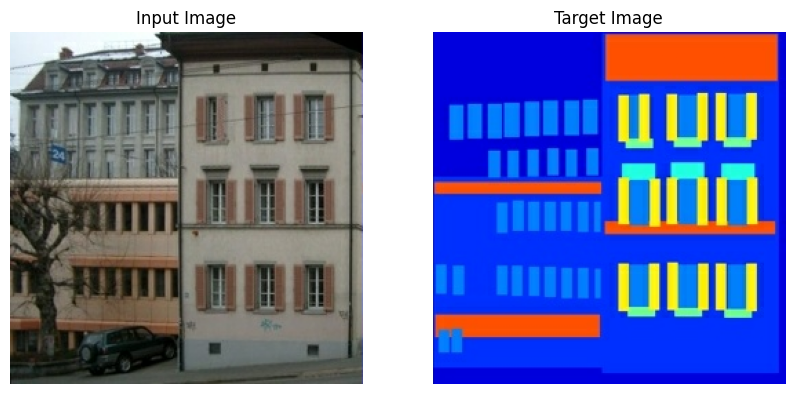

In [13]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(input_image / 255.0)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(target_image / 255.0)
plt.title("Target Image")
plt.axis("off")

plt.show()

In [14]:
def resize_images(input_image, target_image):
    input_image = tf.image.resize(
        input_image,
        [286, 286],
        method=tf.image.ResizeMethod.NEAREST_NEIGHBOR
    )

    target_image = tf.image.resize(
        target_image,
        [286, 286],
        method=tf.image.ResizeMethod.NEAREST_NEIGHBOR
    )

    return input_image, target_image

In [15]:
def random_crop(input_image, target_image):
    stacked_image = tf.stack([input_image, target_image], axis=0)

    cropped_image = tf.image.random_crop(
        stacked_image,
        size=[2, IMG_HEIGHT, IMG_WIDTH, 3]
    )

    return cropped_image[0], cropped_image[1]

In [16]:
def random_jitter(input_image, target_image):

    input_image, target_image = resize_images(
        input_image,
        target_image
    )

    input_image, target_image = random_crop(
        input_image,
        target_image
    )

    # Random horizontal flip
    if tf.random.uniform(()) > 0.5:
        input_image = tf.image.flip_left_right(input_image)
        target_image = tf.image.flip_left_right(target_image)

    return input_image, target_image

In [17]:
def normalize(input_image, target_image):

    input_image = (input_image / 127.5) - 1
    target_image = (target_image / 127.5) - 1

    return input_image, target_image

In [18]:
def preprocess_image(image_file):

    input_image, target_image = load_image(image_file)

    input_image, target_image = random_jitter(
        input_image,
        target_image
    )

    input_image, target_image = normalize(
        input_image,
        target_image
    )

    return input_image, target_image

In [19]:
input_image, target_image = preprocess_image(sample_file)

print("Input shape:", input_image.shape)
print("Target shape:", target_image.shape)

print("Input minimum:", tf.reduce_min(input_image).numpy())
print("Input maximum:", tf.reduce_max(input_image).numpy())

Input shape: (256, 256, 3)
Target shape: (256, 256, 3)
Input minimum: -1.0
Input maximum: 1.0


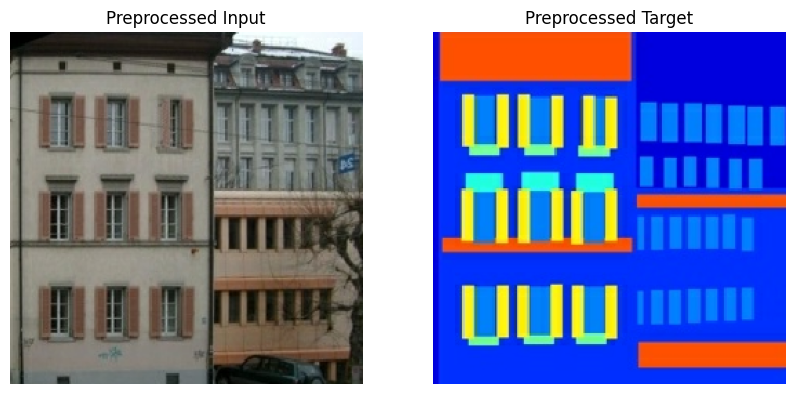

In [20]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow((input_image + 1) / 2)
plt.title("Preprocessed Input")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow((target_image + 1) / 2)
plt.title("Preprocessed Target")
plt.axis("off")

plt.show()

In [21]:
OUTPUT_CHANNELS = 3


def downsample(filters, size, apply_batchnorm=True):
    initializer = tf.random_normal_initializer(0., 0.02)

    layer = tf.keras.Sequential()

    layer.add(
        layers.Conv2D(
            filters,
            size,
            strides=2,
            padding="same",
            kernel_initializer=initializer,
            use_bias=False
        )
    )

    if apply_batchnorm:
        layer.add(layers.BatchNormalization())

    layer.add(layers.LeakyReLU())

    return layer


def upsample(filters, size, apply_dropout=False):
    initializer = tf.random_normal_initializer(0., 0.02)

    layer = tf.keras.Sequential()

    layer.add(
        layers.Conv2DTranspose(
            filters,
            size,
            strides=2,
            padding="same",
            kernel_initializer=initializer,
            use_bias=False
        )
    )

    layer.add(layers.BatchNormalization())

    if apply_dropout:
        layer.add(layers.Dropout(0.5))

    layer.add(layers.ReLU())

    return layer

In [22]:
def Generator():

    inputs = layers.Input(shape=[256, 256, 3])

    # Encoder
    down_stack = [
        downsample(64, 4, apply_batchnorm=False),
        downsample(128, 4),
        downsample(256, 4),
        downsample(512, 4),
        downsample(512, 4),
        downsample(512, 4),
        downsample(512, 4),
        downsample(512, 4),
    ]

    # Decoder
    up_stack = [
        upsample(512, 4, apply_dropout=True),
        upsample(512, 4, apply_dropout=True),
        upsample(512, 4, apply_dropout=True),
        upsample(512, 4),
        upsample(512, 4),
        upsample(256, 4),
        upsample(128, 4),
        upsample(64, 4),
    ]

    initializer = tf.random_normal_initializer(0., 0.02)

    last = layers.Conv2DTranspose(
        OUTPUT_CHANNELS,
        4,
        strides=2,
        padding="same",
        kernel_initializer=initializer,
        activation="tanh"
    )

    x = inputs

    skips = []

    # Encoder
    for down in down_stack:
        x = down(x)
        skips.append(x)

    # Reverse skip connections
    skips = reversed(skips[:-1])

    # Decoder
    for up, skip in zip(up_stack, skips):
        x = up(x)
        x = layers.Concatenate()([x, skip])

    x = last(x)

    return tf.keras.Model(inputs=inputs, outputs=x)

In [23]:
generator = Generator()

generator.summary()

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 128, 128,  │      3,072 │ input_layer[0][0] │
│ (Sequential)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 64, 64,    │    131,584 │ sequential[0][0]  │
│ (Sequential)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 32, 32,    │    525,312 │ sequential_1[0][… │
│ (Sequential)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_3        │ (None, 16, 16,    │  2,099,200 │ sequential_2[0][… │
│ (Sequential)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_4        │ (None, 8, 8, 512) │  4,196,352 │ sequential_3[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_5        │ (None, 4, 4, 512) │  4,196,352 │ sequential_4[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_6        │ (None, 2, 2, 512) │  4,196,352 │ sequential_5[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_7        │ (None, 1, 1, 512) │  4,196,352 │ sequential_6[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_8        │ (None, 2, 2, 512) │  4,196,352 │ sequential_7[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2, 2,      │          0 │ sequential_8[0][… │
│ (Concatenate)       │ 1024)             │            │ sequential_6[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_9        │ (None, 4, 4, 512) │  8,390,656 │ concatenate[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 4, 4,      │          0 │ sequential_9[0][… │
│ (Concatenate)       │ 1024)             │            │ sequential_5[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_10       │ (None, 8, 8, 512) │  8,390,656 │ concatenate_1[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 8, 8,      │          0 │ sequential_10[0]… │
│ (Concatenate)       │ 1024)             │            │ sequential_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_11       │ (None, 16, 16,    │  8,390,656 │ concatenate_2[0]… │
│ (Sequential)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 16, 16,    │          0 │ sequential_11[0]

 Total params: 61,246,467 (233.64 MB)

 Trainable params: 61,234,691 (233.59 MB)

 Non-trainable params: 11,776 (46.00 KB)

In [24]:
test_input = tf.expand_dims(input_image, axis=0)

generated_image = generator(test_input, training=False)

print("Input shape:", test_input.shape)
print("Generated image shape:", generated_image.shape)

Input shape: (1, 256, 256, 3)
Generated image shape: (1, 256, 256, 3)


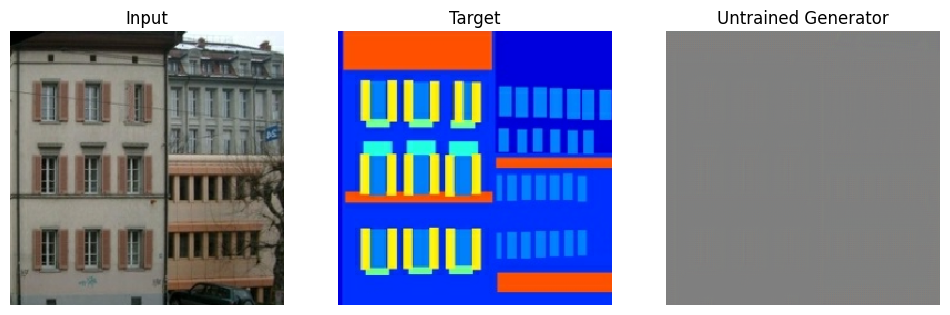

In [25]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow((input_image + 1) / 2)
plt.title("Input")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow((target_image + 1) / 2)
plt.title("Target")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow((generated_image[0] + 1) / 2)
plt.title("Untrained Generator")
plt.axis("off")

plt.show()

In [1]:
def Discriminator():

    initializer = tf.random_normal_initializer(0., 0.02)

    # Input image
    inp = layers.Input(shape=[256, 256, 3], name="input_image")

    # Target or generated image
    tar = layers.Input(shape=[256, 256, 3], name="target_image")

    # Combine input and target
    x = layers.concatenate([inp, tar])

    down1 = downsample(64, 4, False)(x)
    down2 = downsample(128, 4)(down1)
    down3 = downsample(256, 4)(down2)

    zero_pad1 = layers.ZeroPadding2D()(down3)

    conv = layers.Conv2D(
        512,
        4,
        strides=1,
        kernel_initializer=initializer,
        use_bias=False
    )(zero_pad1)

    batchnorm1 = layers.BatchNormalization()(conv)

    leaky_relu = layers.LeakyReLU()(batchnorm1)

    zero_pad2 = layers.ZeroPadding2D()(leaky_relu)

    last = layers.Conv2D(
        1,
        4,
        strides=1,
        kernel_initializer=initializer
    )(zero_pad2)

    return tf.keras.Model(
        inputs=[inp, tar],
        outputs=last
    )

In [2]:
discriminator = Discriminator()

discriminator.summary()

NameError: name 'tf' is not defined

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
def downsample(filters, size, apply_batchnorm=True):
    initializer = tf.random_normal_initializer(0., 0.02)

    layer = tf.keras.Sequential()

    layer.add(
        layers.Conv2D(
            filters,
            size,
            strides=2,
            padding="same",
            kernel_initializer=initializer,
            use_bias=False
        )
    )

    if apply_batchnorm:
        layer.add(layers.BatchNormalization())

    layer.add(layers.LeakyReLU())

    return layer

In [5]:
def Discriminator():

    initializer = tf.random_normal_initializer(0., 0.02)

    inp = layers.Input(
        shape=[256, 256, 3],
        name="input_image"
    )

    tar = layers.Input(
        shape=[256, 256, 3],
        name="target_image"
    )

    x = layers.concatenate([inp, tar])

    down1 = downsample(64, 4, False)(x)
    down2 = downsample(128, 4)(down1)
    down3 = downsample(256, 4)(down2)

    zero_pad1 = layers.ZeroPadding2D()(down3)

    conv = layers.Conv2D(
        512,
        4,
        strides=1,
        kernel_initializer=initializer,
        use_bias=False
    )(zero_pad1)

    batchnorm1 = layers.BatchNormalization()(conv)

    leaky_relu = layers.LeakyReLU()(batchnorm1)

    zero_pad2 = layers.ZeroPadding2D()(leaky_relu)

    last = layers.Conv2D(
        1,
        4,
        strides=1,
        kernel_initializer=initializer
    )(zero_pad2)

    return tf.keras.Model(
        inputs=[inp, tar],
        outputs=last
    )

In [6]:
discriminator = Discriminator()

discriminator.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ target_image        │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256, 256,  │          0 │ input_image[0][0… │
│ (Concatenate)       │ 6)                │            │ target_image[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 128, 128,  │      6,144 │ concatenate[0][0] │
│ (Sequential)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 64, 64,    │    131,584 │ sequential[0][0]  │
│ (Sequential)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 32, 32,    │    525,312 │ sequential_1[0][… │
│ (Sequential)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 34, 34,    │          0 │ sequential_2[0][… │
│ (ZeroPadding2D)     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 31, 31,    │  2,097,152 │ zero_padding2d[0… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 31,    │      2,048 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 31, 31,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 33, 33,    │          0 │ leaky_re_lu_3[0]… │
│ (ZeroPadding2D)     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 30, 30, 1) │      8,193 │ zero_padding2d_1… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,770,433 (10.57 MB)

 Trainable params: 2,768,641 (10.56 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [7]:
decision = discriminator(
    [test_input, tf.expand_dims(target_image, axis=0)],
    training=False
)

print("Discriminator output shape:", decision.shape)

NameError: name 'test_input' is not defined

In [8]:
# Create a test input from one sample image

sample_file = os.path.join(train_path, train_images[0])

input_image, target_image = load_image(sample_file)

# Add batch dimension
test_input = tf.expand_dims(input_image, axis=0)
test_target = tf.expand_dims(target_image, axis=0)

print("Test input shape:", test_input.shape)
print("Test target shape:", test_target.shape)

NameError: name 'os' is not defined

In [9]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers

# Dataset path
PATH = "/content/facades"
train_path = os.path.join(PATH, "train")

# Get training images
train_images = os.listdir(train_path)

print("TensorFlow:", tf.__version__)
print("Training images:", len(train_images))
print("GPU:", tf.config.list_physical_devices("GPU"))

FileNotFoundError: [Errno 2] No such file or directory: '/content/facades/train'

In [10]:
import os
import tarfile
import urllib.request

url = "http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/facades.tar.gz"

download_path = "/content/facades.tar.gz"
extract_path = "/content"

print("Downloading Facades dataset...")

urllib.request.urlretrieve(url, download_path)

print("Download completed!")
print("Extracting dataset...")

with tarfile.open(download_path, "r:gz") as tar:
    tar.extractall(path=extract_path)

print("Extraction completed!")

PATH = "/content/facades"

print("Dataset exists:", os.path.exists(PATH))
print("Dataset folders:", os.listdir(PATH))

Download completed!
Extracting dataset...


/tmp/ipykernel_475/4275801328.py:18: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_path)


Extraction completed!
Dataset exists: True
Dataset folders: ['val', 'test', 'train']


In [11]:
train_path = os.path.join(PATH, "train")
train_images = os.listdir(train_path)

print("Number of training images:", len(train_images))
print("First 5 images:", train_images[:5])

Number of training images: 400
First 5 images: ['120.jpg', '222.jpg', '111.jpg', '101.jpg', '389.jpg']


In [12]:
# Get one sample image

sample_file = os.path.join(train_path, train_images[0])

input_image, target_image = load_image(sample_file)

test_input = tf.expand_dims(input_image, axis=0)
test_target = tf.expand_dims(target_image, axis=0)

print("Test input shape:", test_input.shape)
print("Test target shape:", test_target.shape)

NameError: name 'load_image' is not defined

In [13]:
def load_image(image_file):
    image = tf.io.read_file(image_file)
    image = tf.io.decode_jpeg(image)
    image = tf.cast(image, tf.float32)

    # Left half = input image
    input_image = image[:, :256, :]

    # Right half = target image
    target_image = image[:, 256:, :]

    return input_image, target_image

print("load_image() is ready!")

load_image() is ready!


In [14]:
sample_file = os.path.join(train_path, train_images[0])

input_image, target_image = load_image(sample_file)

test_input = tf.expand_dims(input_image, axis=0)
test_target = tf.expand_dims(target_image, axis=0)

print("Test input shape:", test_input.shape)
print("Test target shape:", test_target.shape)

Test input shape: (1, 256, 256, 3)
Test target shape: (1, 256, 256, 3)


In [15]:
decision = discriminator(
    [test_input, test_target],
    training=False
)

print("Discriminator output shape:", decision.shape)

Discriminator output shape: (1, 30, 30, 1)


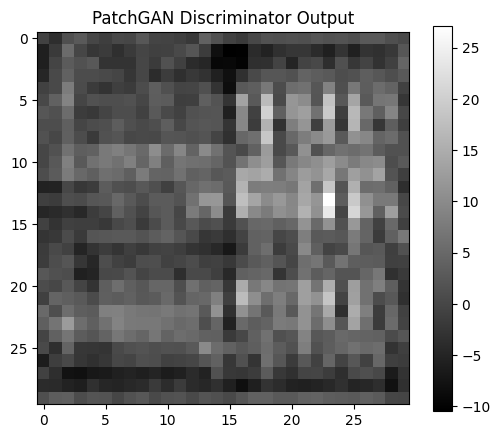

In [16]:
plt.figure(figsize=(6, 5))
plt.imshow(decision[0, :, :, 0], cmap="gray")
plt.title("PatchGAN Discriminator Output")
plt.colorbar()
plt.show()

In [17]:
# Binary Cross-Entropy loss
loss_object = tf.keras.losses.BinaryCrossentropy(from_logits=True)

# Weight for L1 reconstruction loss
LAMBDA = 100


def discriminator_loss(disc_real_output, disc_generated_output):
    # Real images should be classified as real (1)
    real_loss = loss_object(
        tf.ones_like(disc_real_output),
        disc_real_output
    )

    # Generated images should be classified as fake (0)
    generated_loss = loss_object(
        tf.zeros_like(disc_generated_output),
        disc_generated_output
    )

    total_disc_loss = real_loss + generated_loss

    return total_disc_loss


def generator_loss(disc_generated_output, gen_output, target):
    # Generator tries to fool discriminator
    gan_loss = loss_object(
        tf.ones_like(disc_generated_output),
        disc_generated_output
    )

    # L1 loss keeps generated image close to target
    l1_loss = tf.reduce_mean(
        tf.abs(target - gen_output)
    )

    # Total generator loss
    total_gen_loss = gan_loss + (LAMBDA * l1_loss)

    return total_gen_loss, gan_loss, l1_loss


print("Loss functions defined successfully!")

Loss functions defined successfully!


In [18]:
# Adam optimizers for Generator and Discriminator

generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

print("Optimizers created successfully!")

Optimizers created successfully!


In [19]:
@tf.function
def train_step(input_image, target_image):

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        # Generate an image
        gen_output = generator(input_image, training=True)

        # Discriminator checks real pair
        disc_real_output = discriminator(
            [input_image, target_image],
            training=True
        )

        # Discriminator checks generated pair
        disc_generated_output = discriminator(
            [input_image, gen_output],
            training=True
        )

        # Calculate losses
        gen_total_loss, gen_gan_loss, gen_l1_loss = generator_loss(
            disc_generated_output,
            gen_output,
            target_image
        )

        disc_loss = discriminator_loss(
            disc_real_output,
            disc_generated_output
        )

    # Calculate gradients
    generator_gradients = gen_tape.gradient(
        gen_total_loss,
        generator.trainable_variables
    )

    discriminator_gradients = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    # Update Generator
    generator_optimizer.apply_gradients(
        zip(generator_gradients, generator.trainable_variables)
    )

    # Update Discriminator
    discriminator_optimizer.apply_gradients(
        zip(discriminator_gradients, discriminator.trainable_variables)
    )

    return gen_total_loss, gen_gan_loss, gen_l1_loss, disc_loss


print("Training step created successfully!")

Training step created successfully!


In [20]:
# Create TensorFlow dataset

AUTOTUNE = tf.data.AUTOTUNE
BUFFER_SIZE = 400
BATCH_SIZE = 1

# Full paths to training images
train_files = [
    os.path.join(train_path, file)
    for file in train_images
]

train_dataset = tf.data.Dataset.from_tensor_slices(train_files)

# Apply preprocessing
train_dataset = train_dataset.map(
    preprocess_image,
    num_parallel_calls=AUTOTUNE
)

# Shuffle, batch and prefetch
train_dataset = train_dataset.shuffle(BUFFER_SIZE)
train_dataset = train_dataset.batch(BATCH_SIZE)
train_dataset = train_dataset.prefetch(AUTOTUNE)

print("Training dataset created successfully!")

NameError: name 'preprocess_image' is not defined

In [21]:
def resize_images(input_image, target_image):
    input_image = tf.image.resize(
        input_image,
        [286, 286],
        method=tf.image.ResizeMethod.NEAREST_NEIGHBOR
    )

    target_image = tf.image.resize(
        target_image,
        [286, 286],
        method=tf.image.ResizeMethod.NEAREST_NEIGHBOR
    )

    return input_image, target_image


def random_crop(input_image, target_image):
    stacked_image = tf.stack(
        [input_image, target_image],
        axis=0
    )

    cropped_image = tf.image.random_crop(
        stacked_image,
        size=[2, 256, 256, 3]
    )

    return cropped_image[0], cropped_image[1]


def random_jitter(input_image, target_image):
    input_image, target_image = resize_images(
        input_image,
        target_image
    )

    input_image, target_image = random_crop(
        input_image,
        target_image
    )

    if tf.random.uniform(()) > 0.5:
        input_image = tf.image.flip_left_right(input_image)
        target_image = tf.image.flip_left_right(target_image)

    return input_image, target_image


def normalize(input_image, target_image):
    input_image = (input_image / 127.5) - 1
    target_image = (target_image / 127.5) - 1

    return input_image, target_image


def preprocess_image(image_file):
    input_image, target_image = load_image(image_file)

    input_image, target_image = random_jitter(
        input_image,
        target_image
    )

    input_image, target_image = normalize(
        input_image,
        target_image
    )

    return input_image, target_image


print("Preprocessing functions restored successfully!")

Preprocessing functions restored successfully!


In [22]:
AUTOTUNE = tf.data.AUTOTUNE
BUFFER_SIZE = 400
BATCH_SIZE = 1

train_files = [
    os.path.join(train_path, file)
    for file in train_images
]

train_dataset = tf.data.Dataset.from_tensor_slices(train_files)

train_dataset = train_dataset.map(
    preprocess_image,
    num_parallel_calls=AUTOTUNE
)

train_dataset = train_dataset.shuffle(BUFFER_SIZE)
train_dataset = train_dataset.batch(BATCH_SIZE)
train_dataset = train_dataset.prefetch(AUTOTUNE)

print("Training dataset created successfully!")

Training dataset created successfully!


In [23]:
for input_batch, target_batch in train_dataset.take(1):
    print("Input batch shape:", input_batch.shape)
    print("Target batch shape:", target_batch.shape)

Input batch shape: (1, 256, 256, 3)
Target batch shape: (1, 256, 256, 3)


In [24]:
# Take one batch from the training dataset

for input_batch, target_batch in train_dataset.take(1):

    gen_total_loss, gen_gan_loss, gen_l1_loss, disc_loss = train_step(
        input_batch,
        target_batch
    )

    print("Generator Total Loss:", float(gen_total_loss))
    print("Generator GAN Loss:", float(gen_gan_loss))
    print("Generator L1 Loss:", float(gen_l1_loss))
    print("Discriminator Loss:", float(disc_loss))

NameError: in user code:

    File "/tmp/ipykernel_475/2230185660.py", line 7, in train_step  *
        gen_output = generator(input_image, training=True)

    NameError: name 'generator' is not defined


In [25]:
def downsample(filters, size, apply_batchnorm=True):
    initializer = tf.random_normal_initializer(0., 0.02)

    layer = tf.keras.Sequential()

    layer.add(
        layers.Conv2D(
            filters,
            size,
            strides=2,
            padding="same",
            kernel_initializer=initializer,
            use_bias=False
        )
    )

    if apply_batchnorm:
        layer.add(layers.BatchNormalization())

    layer.add(layers.LeakyReLU())

    return layer


def upsample(filters, size, apply_dropout=False):
    initializer = tf.random_normal_initializer(0., 0.02)

    layer = tf.keras.Sequential()

    layer.add(
        layers.Conv2DTranspose(
            filters,
            size,
            strides=2,
            padding="same",
            kernel_initializer=initializer,
            use_bias=False
        )
    )

    layer.add(layers.BatchNormalization())

    if apply_dropout:
        layer.add(layers.Dropout(0.5))

    layer.add(layers.ReLU())

    return layer


def Generator():

    inputs = layers.Input(shape=[256, 256, 3])

    down_stack = [
        downsample(64, 4, apply_batchnorm=False),
        downsample(128, 4),
        downsample(256, 4),
        downsample(512, 4),
        downsample(512, 4),
        downsample(512, 4),
        downsample(512, 4),
        downsample(512, 4),
    ]

    up_stack = [
        upsample(512, 4, apply_dropout=True),
        upsample(512, 4, apply_dropout=True),
        upsample(512, 4, apply_dropout=True),
        upsample(512, 4),
        upsample(512, 4),
        upsample(256, 4),
        upsample(128, 4),
        upsample(64, 4),
    ]

    initializer = tf.random_normal_initializer(0., 0.02)

    last = layers.Conv2DTranspose(
        3,
        4,
        strides=2,
        padding="same",
        kernel_initializer=initializer,
        activation="tanh"
    )

    x = inputs
    skips = []

    for down in down_stack:
        x = down(x)
        skips.append(x)

    skips = reversed(skips[:-1])

    for up, skip in zip(up_stack, skips):
        x = up(x)
        x = layers.Concatenate()([x, skip])

    x = last(x)

    return tf.keras.Model(inputs=inputs, outputs=x)


# Create the Generator model
generator = Generator()

print("Generator created successfully!")

Generator created successfully!


In [26]:
test_output = generator(test_input, training=False)

print("Generated image shape:", test_output.shape)

Generated image shape: (1, 256, 256, 3)


In [27]:
def Discriminator():

    initializer = tf.random_normal_initializer(0., 0.02)

    inp = layers.Input(
        shape=[256, 256, 3],
        name="input_image"
    )

    tar = layers.Input(
        shape=[256, 256, 3],
        name="target_image"
    )

    # Combine input and target/generated image
    x = layers.concatenate([inp, tar])

    down1 = downsample(64, 4, False)(x)
    down2 = downsample(128, 4)(down1)
    down3 = downsample(256, 4)(down2)

    zero_pad1 = layers.ZeroPadding2D()(down3)

    conv = layers.Conv2D(
        512,
        4,
        strides=1,
        kernel_initializer=initializer,
        use_bias=False
    )(zero_pad1)

    batchnorm1 = layers.BatchNormalization()(conv)
    leaky_relu = layers.LeakyReLU()(batchnorm1)

    zero_pad2 = layers.ZeroPadding2D()(leaky_relu)

    last = layers.Conv2D(
        1,
        4,
        strides=1,
        kernel_initializer=initializer
    )(zero_pad2)

    return tf.keras.Model(
        inputs=[inp, tar],
        outputs=last
    )


# Create the Discriminator
discriminator = Discriminator()

print("Discriminator created successfully!")

Discriminator created successfully!


In [28]:
decision = discriminator(
    [test_input, test_target],
    training=False
)

print("Discriminator output shape:", decision.shape)

Discriminator output shape: (1, 30, 30, 1)


In [29]:
for input_batch, target_batch in train_dataset.take(1):

    gen_total_loss, gen_gan_loss, gen_l1_loss, disc_loss = train_step(
        input_batch,
        target_batch
    )

    print("Generator Total Loss:", float(gen_total_loss))
    print("Generator GAN Loss:", float(gen_gan_loss))
    print("Generator L1 Loss:", float(gen_l1_loss))
    print("Discriminator Loss:", float(disc_loss))

ValueError: Creating variables on a non-first call to a function decorated with tf.function.

In [30]:
def train_step(input_image, target_image):

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        # Generate image
        gen_output = generator(input_image, training=True)

        # Discriminator on real pair
        disc_real_output = discriminator(
            [input_image, target_image],
            training=True
        )

        # Discriminator on generated pair
        disc_generated_output = discriminator(
            [input_image, gen_output],
            training=True
        )

        # Calculate losses
        gen_total_loss, gen_gan_loss, gen_l1_loss = generator_loss(
            disc_generated_output,
            gen_output,
            target_image
        )

        disc_loss = discriminator_loss(
            disc_real_output,
            disc_generated_output
        )

    # Calculate gradients
    generator_gradients = gen_tape.gradient(
        gen_total_loss,
        generator.trainable_variables
    )

    discriminator_gradients = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    # Update models
    generator_optimizer.apply_gradients(
        zip(generator_gradients, generator.trainable_variables)
    )

    discriminator_optimizer.apply_gradients(
        zip(discriminator_gradients, discriminator.trainable_variables)
    )

    return gen_total_loss, gen_gan_loss, gen_l1_loss, disc_loss


print("Training step reset successfully!")

Training step reset successfully!


In [31]:
for input_batch, target_batch in train_dataset.take(1):

    gen_total_loss, gen_gan_loss, gen_l1_loss, disc_loss = train_step(
        input_batch,
        target_batch
    )

    print("Generator Total Loss:", float(gen_total_loss))
    print("Generator GAN Loss:", float(gen_gan_loss))
    print("Generator L1 Loss:", float(gen_l1_loss))
    print("Discriminator Loss:", float(disc_loss))

Generator Total Loss: 84.0413818359375
Generator GAN Loss: 1.286094307899475
Generator L1 Loss: 0.827552855014801
Discriminator Loss: 2.5191798210144043


In [32]:
# Training configuration

EPOCHS = 5
STEPS_PER_EPOCH = 400

print("Starting training...")

Starting training...


In [33]:
import time

gen_losses = []
disc_losses = []

for epoch in range(EPOCHS):

    start = time.time()

    epoch_gen_loss = []
    epoch_disc_loss = []

    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    for step, (input_batch, target_batch) in enumerate(train_dataset):

        gen_total_loss, gen_gan_loss, gen_l1_loss, disc_loss = train_step(
            input_batch,
            target_batch
        )

        epoch_gen_loss.append(float(gen_total_loss))
        epoch_disc_loss.append(float(disc_loss))

        if (step + 1) % 100 == 0:
            print(
                f"Step {step + 1}: "
                f"Gen Loss = {float(gen_total_loss):.4f}, "
                f"Disc Loss = {float(disc_loss):.4f}"
            )

        # Stop after 400 steps
        if step + 1 >= STEPS_PER_EPOCH:
            break

    # Average losses for the epoch
    avg_gen_loss = np.mean(epoch_gen_loss)
    avg_disc_loss = np.mean(epoch_disc_loss)

    gen_losses.append(avg_gen_loss)
    disc_losses.append(avg_disc_loss)

    print(
        f"Epoch {epoch + 1} completed | "
        f"Generator Loss: {avg_gen_loss:.4f} | "
        f"Discriminator Loss: {avg_disc_loss:.4f} | "
        f"Time: {time.time() - start:.2f}s"
    )

print("\nTraining completed successfully!")


Epoch 1/5
Step 100: Gen Loss = 40.8263, Disc Loss = 0.8660
Step 200: Gen Loss = 48.3077, Disc Loss = 2.0004
Step 300: Gen Loss = 36.6279, Disc Loss = 1.7697
Step 400: Gen Loss = 59.6521, Disc Loss = 0.1172
Epoch 1 completed | Generator Loss: 46.4639 | Discriminator Loss: 0.7337 | Time: 288.79s

Epoch 2/5
Step 100: Gen Loss = 38.8670, Disc Loss = 1.6566
Step 200: Gen Loss = 32.1895, Disc Loss = 0.5837
Step 300: Gen Loss = 40.8285, Disc Loss = 0.2307
Step 400: Gen Loss = 52.0435, Disc Loss = 0.2236
Epoch 2 completed | Generator Loss: 43.2703 | Discriminator Loss: 0.6327 | Time: 286.00s

Epoch 3/5
Step 100: Gen Loss = 39.2449, Disc Loss = 0.6133
Step 200: Gen Loss = 43.1163, Disc Loss = 0.7713
Step 300: Gen Loss = 21.6680, Disc Loss = 1.4824
Step 400: Gen Loss = 55.1397, Disc Loss = 0.5714
Epoch 3 completed | Generator Loss: 42.0472 | Discriminator Loss: 0.5968 | Time: 282.28s

Epoch 4/5
Step 100: Gen Loss = 36.9049, Disc Loss = 0.5807
Step 200: Gen Loss = 36.8899, Disc Loss = 0.7209
Ste

In [34]:
def generate_result(model, image_file):
    input_image, target_image = load_image_test(image_file)

    prediction = model(
        tf.expand_dims(input_image, axis=0),
        training=False
    )

    return input_image, target_image, prediction[0]

In [35]:
def load_image_test(image_file):
    input_image, target_image = load_image(image_file)

    input_image = tf.image.resize(
        input_image,
        [256, 256],
        method=tf.image.ResizeMethod.NEAREST_NEIGHBOR
    )

    target_image = tf.image.resize(
        target_image,
        [256, 256],
        method=tf.image.ResizeMethod.NEAREST_NEIGHBOR
    )

    input_image = (input_image / 127.5) - 1
    target_image = (target_image / 127.5) - 1

    return input_image, target_image

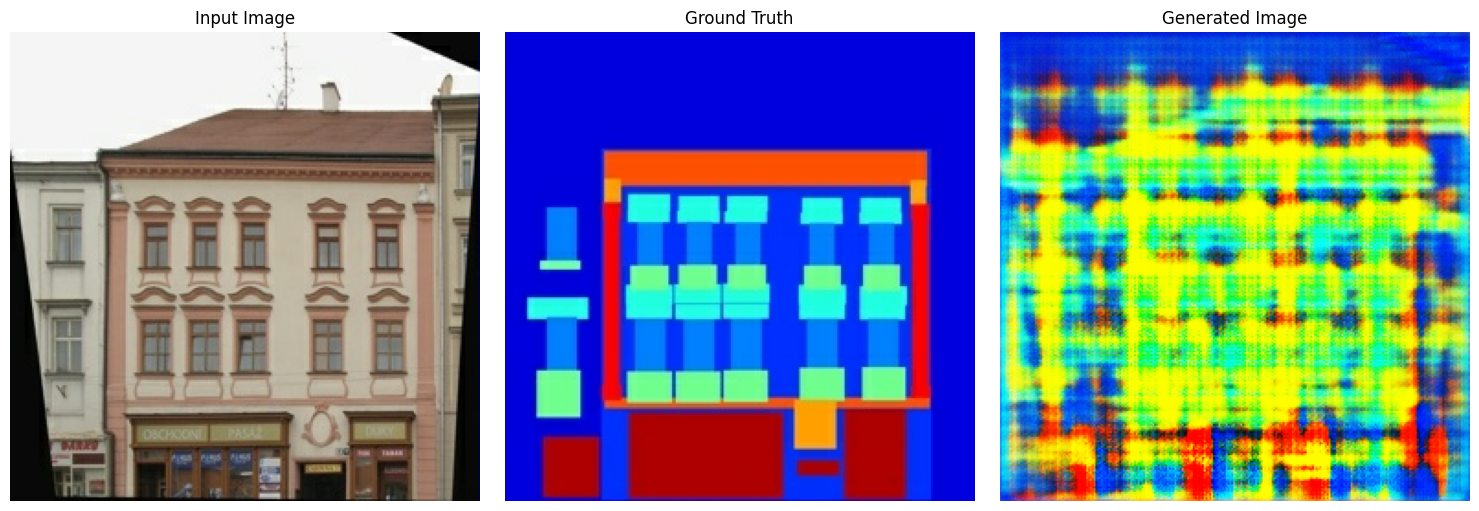

In [36]:
test_path = os.path.join(PATH, "test")
test_images = os.listdir(test_path)

test_file = os.path.join(test_path, test_images[0])

input_image, target_image, prediction = generate_result(
    generator,
    test_file
)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow((input_image + 1) / 2)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow((target_image + 1) / 2)
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow((prediction + 1) / 2)
plt.title("Generated Image")
plt.axis("off")

plt.tight_layout()
plt.show()

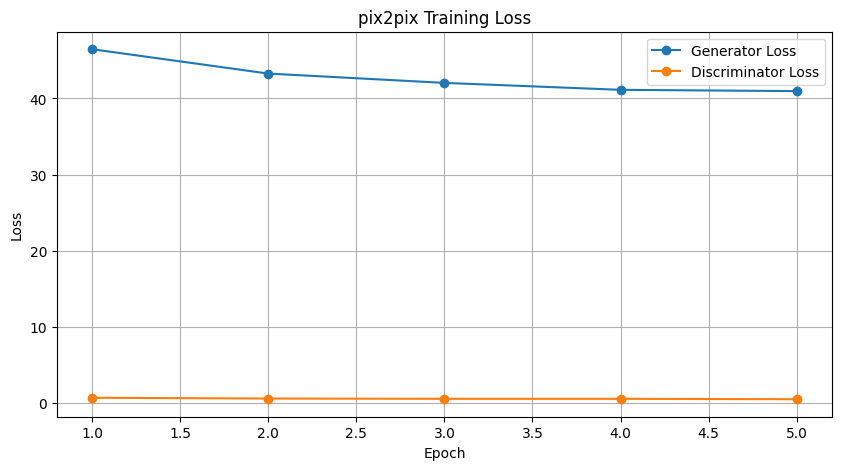

In [37]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(gen_losses) + 1),
    gen_losses,
    marker="o",
    label="Generator Loss"
)

plt.plot(
    range(1, len(disc_losses) + 1),
    disc_losses,
    marker="o",
    label="Discriminator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("pix2pix Training Loss")
plt.legend()
plt.grid(True)

plt.show()

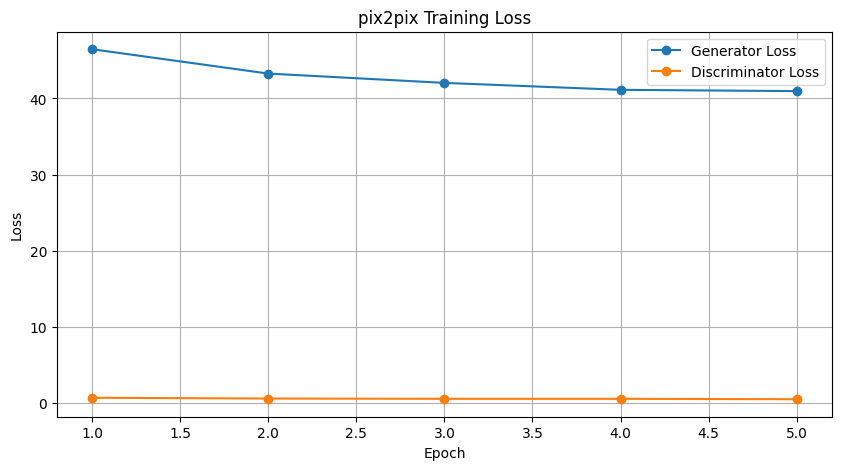

Loss graph saved successfully!


In [38]:
os.makedirs("/content/results", exist_ok=True)

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(gen_losses) + 1),
    gen_losses,
    marker="o",
    label="Generator Loss"
)

plt.plot(
    range(1, len(disc_losses) + 1),
    disc_losses,
    marker="o",
    label="Discriminator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("pix2pix Training Loss")
plt.legend()
plt.grid(True)

plt.savefig(
    "/content/results/training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Loss graph saved successfully!")

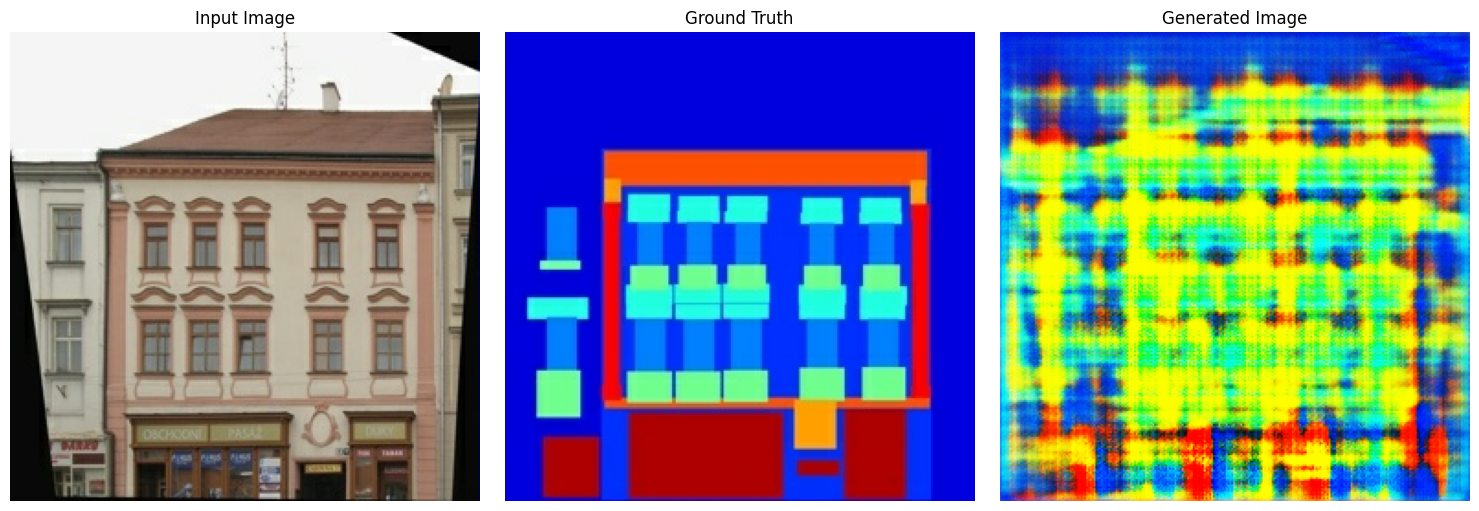

Generated result saved successfully!


In [39]:
import os
import matplotlib.pyplot as plt

os.makedirs("/content/results", exist_ok=True)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow((input_image + 1) / 2)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow((target_image + 1) / 2)
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow((prediction + 1) / 2)
plt.title("Generated Image")
plt.axis("off")

plt.tight_layout()

plt.savefig(
    "/content/results/generated_result.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Generated result saved successfully!")

In [40]:
generator.save("/content/results/pix2pix_generator.keras")

print("Generator model saved successfully!")

Generator model saved successfully!


In [41]:
import os

results_path = "/content/results"

print("Files in results folder:")
for file in os.listdir(results_path):
    print("✔", file)

Files in results folder:
✔ generated_result.png
✔ pix2pix_generator.keras
✔ training_loss.png


In [42]:
from google.colab import files

files.download("/content/results/generated_result.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [43]:
files.download("/content/results/training_loss.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
files.download("/content/results/pix2pix_generator.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>